# 1. Business Understanding

## Objective
The objective of this project is to design and implement a predictive credit risk scoring system to identify high-risk loan applicants and support data-driven lending decisions.

## Business Problem
Financial institutions must minimize loan default risk while maintaining healthy loan portfolio growth. Predicting borrower default probability enables risk-based pricing, approval strategies, and capital allocation.

## Target Variable
Default:
0 = Non-default (loan successfully repaid)
1 = Default (loan failed or charged-off)

## Analytical Goals
1. Identify key drivers of loan default.
2. Develop a predictive model to estimate probability of default.
3. Convert predictions into actionable risk tiers.
4. Build an executive dashboard for portfolio monitoring.

## Success Metrics
- ROC-AUC score
- Recall on default class
- Precision on high-risk predictions
- Interpretability of key risk drivers

In [4]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("LC_loans_granting_model_dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

/var/folders/tv/65fm8gl968v8bvb1dnkdxjsw0000gn/T/ipykernel_60802/3220289926.py:5: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("LC_loans_granting_model_dataset.csv")


Dataset Shape: (1347681, 15)


,id,issue_d,revenue,dti_n,loan_amnt,fico_n,experience_c,emp_length,purpose,home_ownership_n,addr_state,zip_code,Default,title,desc
0,68407277,Dec-2015,55000.0,5.91,3600,677.0,1,10+ years,debt_consolidation,MORTGAGE,PA,190xx,0,Debt consolidation,NaN
1,68355089,Dec-2015,65000.0,16.06,24700,717.0,1,10+ years,small_business,MORTGAGE,SD,577xx,0,Business,NaN
2,68341763,Dec-2015,71000.0,13.85,20000,697.0,1,10+ years,home_improvement,MORTGAGE,IL,605xx,0,NaN,NaN
3,68476807,Dec-2015,104433.0,25.37,10400,697.0,1,3 years,major_purchase,MORTGAGE,PA,174xx,0,Major purchase,NaN
4,68426831,Dec-2015,34000.0,10.20,11950,692.0,1,4 years,debt_consolidation,RENT,GA,300xx,0,Debt consolidation,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1347681 entries, 0 to 1347680
Data columns (total 15 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   id                1347681 non-null  int64  
 1   issue_d           1347681 non-null  object 
 2   revenue           1347681 non-null  float64
 3   dti_n             1347681 non-null  float64
 4   loan_amnt         1347681 non-null  int64  
 5   fico_n            1347681 non-null  float64
 6   experience_c      1347681 non-null  int64  
 7   emp_length        1347681 non-null  object 
 8   purpose           1347681 non-null  object 
 9   home_ownership_n  1347681 non-null  object 
 10  addr_state        1347681 non-null  object 
 11  zip_code          1347680 non-null  object 
 12  Default           1347681 non-null  int64  
 13  title             1331024 non-null  object 
 14  desc              119099 non-null   object 
dtypes: float64(3), int64(4), object(8)
memory usage: 

In [6]:
missing = df.isna().mean().sort_values(ascending=False)
missing.head(10)

desc            9.116267e-01
title           1.235975e-02
zip_code        7.420154e-07
id              0.000000e+00
issue_d         0.000000e+00
revenue         0.000000e+00
dti_n           0.000000e+00
loan_amnt       0.000000e+00
fico_n          0.000000e+00
experience_c    0.000000e+00
dtype: float64

In [7]:
# Drop irrelevant / high-missing columns
df = df.drop(columns=['desc', 'title', 'id'])

print("New shape:", df.shape)

New shape: (1347681, 12)


In [8]:
df['Default'].value_counts()
df['Default'].value_counts(normalize=True)

Default
0    0.800213
1    0.199787
Name: proportion, dtype: float64

### Feature Engineering

In [10]:
df['emp_length'].unique()

array(['10+ years', '3 years', '4 years', '6 years', '7 years', '8 years',
       '2 years', '5 years', '9 years', '< 1 year', '1 year', 'NI'],
      dtype=object)

In [11]:
def convert_emp_length(x):
    if x == '10+ years':
        return 10
    elif x == '< 1 year':
        return 0
    elif x == 'NI':
        return 0
    else:
        return int(x.split()[0])

df['emp_length_num'] = df['emp_length'].apply(convert_emp_length)

df[['emp_length', 'emp_length_num']].head()

,emp_length,emp_length_num
0,10+ years,10
1,10+ years,10
2,10+ years,10
3,3 years,3
4,4 years,4


Loan-to-Income Ratio (LTI):

In credit risk modeling, one of the strongest predictors is:
Loan-to-Income Ratio = loan amount / annual income

This captures repayment burden relative to earnings.

In [13]:
df['loan_to_income'] = df['loan_amnt'] / df['revenue'].replace(0, np.nan)
df['loan_to_income'].describe()

count    1.347681e+06
mean     2.105219e-01
std      1.124879e-01
min      1.714286e-04
25%      1.228102e-01
50%      1.966292e-01
75%      2.857143e-01
max      1.337500e+00
Name: loan_to_income, dtype: float64

In [14]:
# Convert issue_d to datetime
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')

# Extract year and month
df['issue_year'] = df['issue_d'].dt.year
df['issue_month'] = df['issue_d'].dt.month

df[['issue_d', 'issue_year', 'issue_month']].head()

,issue_d,issue_year,issue_month
0,2015-12-01,2015,12
1,2015-12-01,2015,12
2,2015-12-01,2015,12
3,2015-12-01,2015,12
4,2015-12-01,2015,12


In [15]:
def fico_bucket(score):
    if score < 650:
        return 'High Risk (<650)'
    elif score < 700:
        return 'Med Risk (650-699)'
    elif score < 750:
        return 'Low Risk (700-750)'
    else:
        return 'Very Low Risk (750+)'

df['fico_bucket'] = df['fico_n'].apply(fico_bucket)

df[['fico_n', 'fico_bucket']].head()

,fico_n,fico_bucket
0,677.0,Med Risk (650-699)
1,717.0,Low Risk (700-750)
2,697.0,Med Risk (650-699)
3,697.0,Med Risk (650-699)
4,692.0,Med Risk (650-699)


In [16]:
def dti_bucket(dti):
    if dti <= 10:
        return 'Very Low (0-10%)'
    elif dti <= 20:
        return 'Low (10-20%)'
    elif dti <= 30:
        return 'Medium (20-30%)'
    elif dti <= 40:
        return 'High (30-40%)'
    else:
        return 'Very High (>40%)'

df['dti_bucket'] = df['dti_n'].apply(dti_bucket)

df[['dti_n', 'dti_bucket']].head()

,dti_n,dti_bucket
0,5.91,Very Low (0-10%)
1,16.06,Low (10-20%)
2,13.85,Low (10-20%)
3,25.37,Medium (20-30%)
4,10.20,Low (10-20%)


In [17]:
# Define target
y = df['Default']

# Feature selection
numeric_features = [
    'revenue',
    'dti_n',
    'loan_amnt',
    'fico_n',
    'experience_c',
    'emp_length_num',
    'loan_to_income',
    'issue_year'
]

categorical_features = [
    'purpose',
    'home_ownership_n',
    'addr_state',
    'fico_bucket',
    'dti_bucket'
]

X = df[numeric_features + categorical_features]

X.head()

,revenue,dti_n,loan_amnt,fico_n,experience_c,emp_length_num,loan_to_income,issue_year,purpose,home_ownership_n,addr_state,fico_bucket,dti_bucket
0,55000.0,5.91,3600,677.0,1,10,0.065455,2015,debt_consolidation,MORTGAGE,PA,Med Risk (650-699),Very Low (0-10%)
1,65000.0,16.06,24700,717.0,1,10,0.380000,2015,small_business,MORTGAGE,SD,Low Risk (700-750),Low (10-20%)
2,71000.0,13.85,20000,697.0,1,10,0.281690,2015,home_improvement,MORTGAGE,IL,Med Risk (650-699),Low (10-20%)
3,104433.0,25.37,10400,697.0,1,3,0.099585,2015,major_purchase,MORTGAGE,PA,Med Risk (650-699),Medium (20-30%)
4,34000.0,10.20,11950,692.0,1,4,0.351471,2015,debt_consolidation,RENT,GA,Med Risk (650-699),Low (10-20%)


In [18]:
from sklearn.model_selection import train_test_split

y = df['Default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1078144, 13)
Test shape: (269537, 13)


In [19]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

numeric_features = [
    'revenue',
    'dti_n',
    'loan_amnt',
    'fico_n',
    'experience_c',
    'emp_length_num',
    'loan_to_income',
    'issue_year'
]

categorical_features = [
    'purpose',
    'home_ownership_n',
    'addr_state',
    'fico_bucket',
    'dti_bucket'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

model = LogisticRegression(class_weight='balanced', max_iter=1000)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

In [20]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['revenue', 'dti_n',
                                                   'loan_amnt', 'fico_n',
                                                   'experience_c',
                                                   'emp_length_num',
                                                   'loan_to_income',
                                                   'issue_year']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['purpose',
                                                   'home_ownership_n',
                                                   'addr_state', 'fico_bucket',
                                                   'dti_bucket'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [21]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.87      0.61      0.71    215687
           1       0.29      0.63      0.39     53850

    accuracy                           0.61    269537
   macro avg       0.58      0.62      0.55    269537
weighted avg       0.75      0.61      0.65    269537

ROC-AUC: 0.6669198844525639


In [22]:
# Risk Score
df_test = X_test.copy()
df_test['Actual_Default'] = y_test
df_test['Default_Probability'] = y_proba

df_test[['Actual_Default', 'Default_Probability']].head()

,Actual_Default,Default_Probability
1298423,0,0.725486
858595,0,0.599899
584294,0,0.542257
1017833,0,0.618329
458764,0,0.348301


In [23]:
df_test['Risk_Band'] = pd.cut(
    df_test['Default_Probability'],
    bins=[0, 0.2, 0.4, 0.6, 1.0],
    labels=['Low Risk', 'Moderate Risk', 'High Risk', 'Very High Risk']
)

df_test['Risk_Band'].value_counts()

Risk_Band
High Risk         128796
Moderate Risk      74903
Very High Risk     56684
Low Risk            9154
Name: count, dtype: int64

In [24]:
pd.crosstab(df_test['Risk_Band'], df_test['Actual_Default'], normalize='index')

Actual_Default,0,1
Risk_Band,,
Low Risk,0.958270,0.041730
Moderate Risk,0.893062,0.106938
High Risk,0.798814,0.201186
Very High Risk,0.655176,0.344824


fico_bucket
Very Low Risk (750+)    0.088821
Low Risk (700-750)      0.156782
Med Risk (650-699)      0.236029
High Risk (<650)        0.320346
Name: Default, dtype: float64


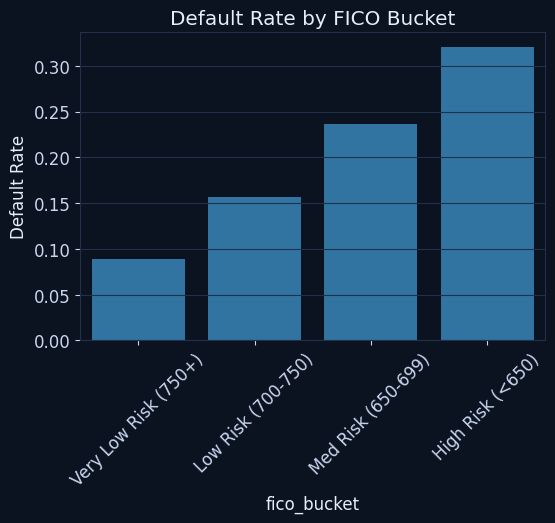

In [25]:
# Default Rate by FICO Bucket

import matplotlib.pyplot as plt
import seaborn as sns

fico_default = (
    df.groupby('fico_bucket')['Default']
    .mean()
    .sort_values()
)

print(fico_default)

plt.figure(figsize=(6,4))
sns.barplot(x=fico_default.index, y=fico_default.values)
plt.title("Default Rate by FICO Bucket")
plt.ylabel("Default Rate")
plt.xticks(rotation=45)
plt.show()

dti_bucket
Very Low (0-10%)    0.148393
Low (10-20%)        0.178543
Medium (20-30%)     0.230801
High (30-40%)       0.291282
Very High (>40%)    0.306731
Name: Default, dtype: float64


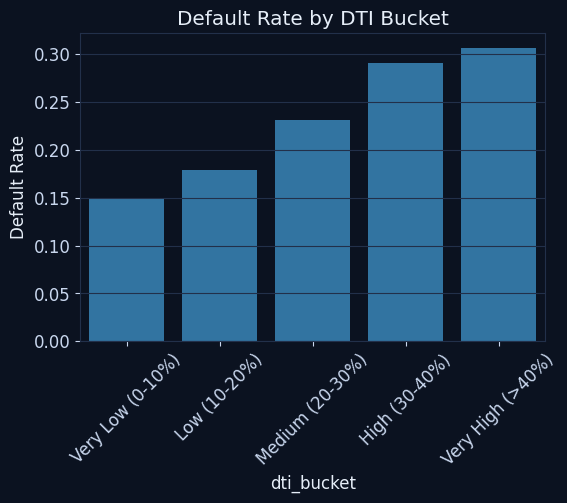

In [26]:
# Default Rate by DTI Bucket

dti_default = (
    df.groupby('dti_bucket')['Default']
    .mean()
    .sort_values()
)

print(dti_default)

plt.figure(figsize=(6,4))
sns.barplot(x=dti_default.index, y=dti_default.values)
plt.title("Default Rate by DTI Bucket")
plt.ylabel("Default Rate")
plt.xticks(rotation=45)
plt.show()

lti_quartile
0    0.138012
1    0.169563
2    0.210298
3    0.281551
Name: Default, dtype: float64


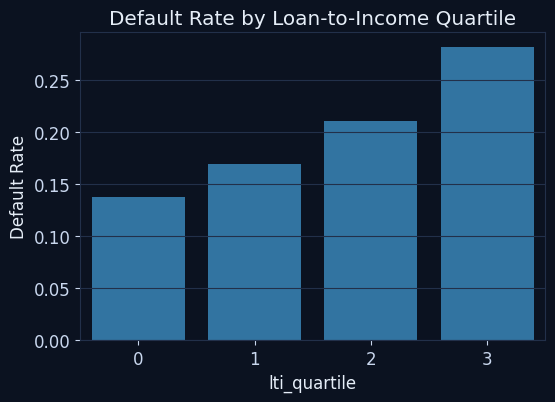

In [27]:
# Default Rate by Loan-to-Income Quartiles

df['lti_quartile'] = pd.qcut(df['loan_to_income'], 4, labels=False)

lti_default = (
    df.groupby('lti_quartile')['Default']
    .mean()
)

print(lti_default)

plt.figure(figsize=(6,4))
sns.barplot(x=lti_default.index, y=lti_default.values)
plt.title("Default Rate by Loan-to-Income Quartile")
plt.ylabel("Default Rate")
plt.show()

purpose
small_business        0.298555
moving                0.234139
medical               0.218442
debt_consolidation    0.211542
other                 0.210840
vacation              0.191897
major_purchase        0.186034
home_improvement      0.177569
credit_card           0.169311
car                   0.146993
Name: Default, dtype: float64


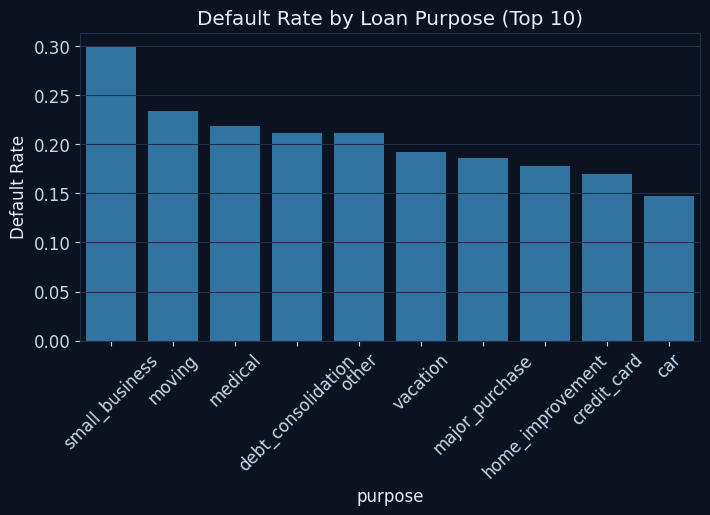

In [28]:
# Default Rate by Purpose (Top 10 Only)

top_purpose = df['purpose'].value_counts().head(10).index

purpose_default = (
    df[df['purpose'].isin(top_purpose)]
    .groupby('purpose')['Default']
    .mean()
    .sort_values(ascending=False)
)

print(purpose_default)

plt.figure(figsize=(8,4))
sns.barplot(x=purpose_default.index, y=purpose_default.values)
plt.title("Default Rate by Loan Purpose (Top 10)")
plt.xticks(rotation=45)
plt.ylabel("Default Rate")
plt.show()

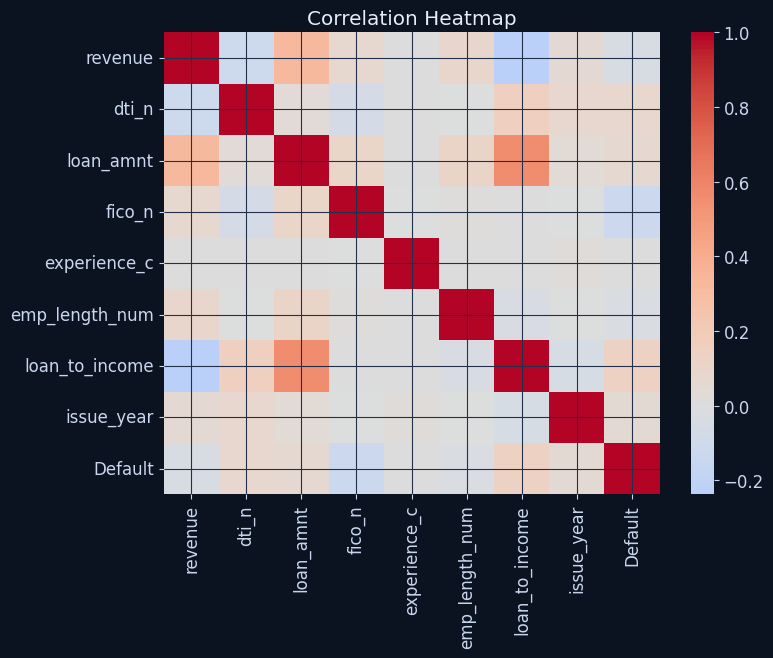

In [29]:
# Correlation Heatmap

numeric_cols = [
    'revenue',
    'dti_n',
    'loan_amnt',
    'fico_n',
    'experience_c',
    'emp_length_num',
    'loan_to_income',
    'issue_year',
    'Default'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

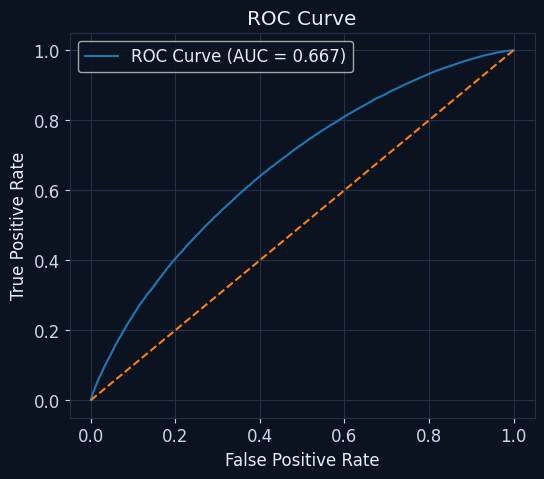

In [30]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

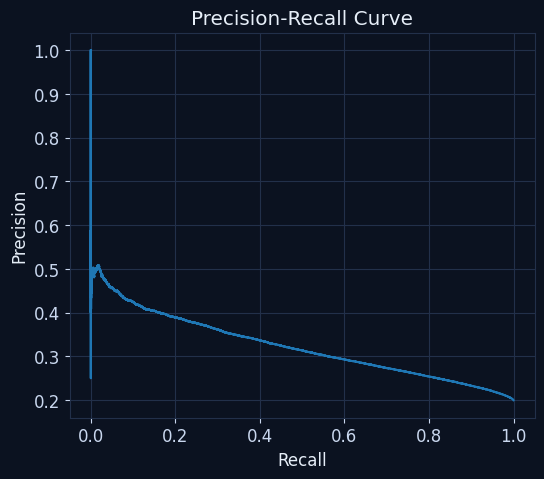

In [31]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

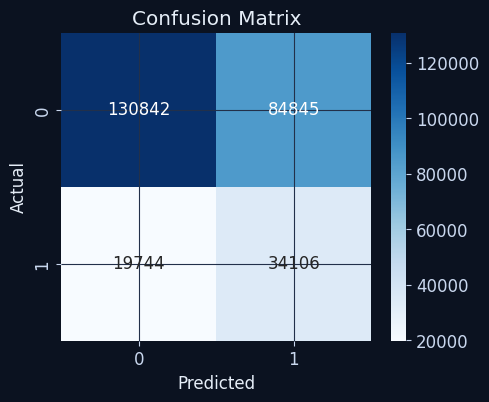

In [32]:
from sklearn.metrics import confusion_matrix

y_pred = pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

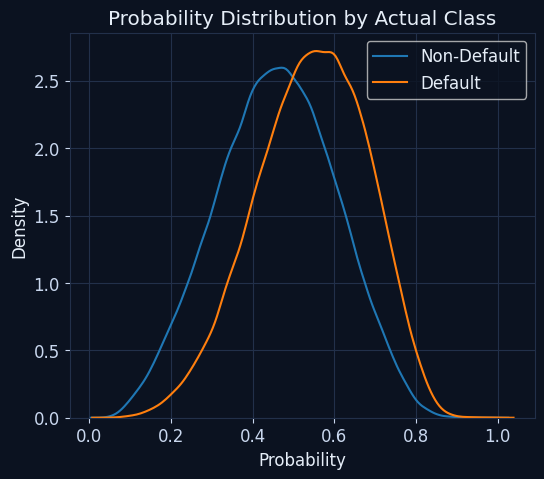

In [33]:
df_test_temp = pd.DataFrame({
    'Actual': y_test,
    'Probability': y_proba
})

plt.figure(figsize=(6,5))
sns.kdeplot(data=df_test_temp[df_test_temp['Actual']==0], 
            x='Probability', label='Non-Default')
sns.kdeplot(data=df_test_temp[df_test_temp['Actual']==1], 
            x='Probability', label='Default')
plt.title('Probability Distribution by Actual Class')
plt.legend()
plt.show()

In [34]:
# Get feature names
num_features = numeric_features
cat_features = pipeline.named_steps['preprocessor'] \
                        .named_transformers_['cat'] \
                        .get_feature_names_out(categorical_features)

all_features = list(num_features) + list(cat_features)

len(all_features)

86

In [35]:
# Extract model coefficients
coefficients = pipeline.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': coefficients
})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

coef_df.head(10)

,Feature,Coefficient
19,purpose_small_business,0.571078
51,addr_state_MS,0.322505
28,addr_state_AR,0.315016
6,loan_to_income,0.303879
27,addr_state_AL,0.300564
44,addr_state_LA,0.296353
62,addr_state_OK,0.285878
81,dti_bucket_High (30-40%),0.274447
84,dti_bucket_Very High (>40%),0.273865
55,addr_state_NE,0.267702


In [36]:
# Features increasing default risk

top_risk = coef_df.sort_values(by='Coefficient', ascending=False).head(10)
top_risk

,Feature,Coefficient
19,purpose_small_business,0.571078
51,addr_state_MS,0.322505
28,addr_state_AR,0.315016
6,loan_to_income,0.303879
27,addr_state_AL,0.300564
44,addr_state_LA,0.296353
62,addr_state_OK,0.285878
81,dti_bucket_High (30-40%),0.274447
84,dti_bucket_Very High (>40%),0.273865
55,addr_state_NE,0.267702


In [37]:
# Features reducing default risk

top_safe = coef_df.sort_values(by='Coefficient').head(10)
top_safe

,Feature,Coefficient
47,addr_state_ME,-0.491314
33,addr_state_DC,-0.482304
9,purpose_credit_card,-0.481968
72,addr_state_VT,-0.427957
3,fico_n,-0.394139
63,addr_state_OR,-0.341814
56,addr_state_NH,-0.289125
21,purpose_wedding,-0.278559
85,dti_bucket_Very Low (0-10%),-0.272760
8,purpose_car,-0.267109


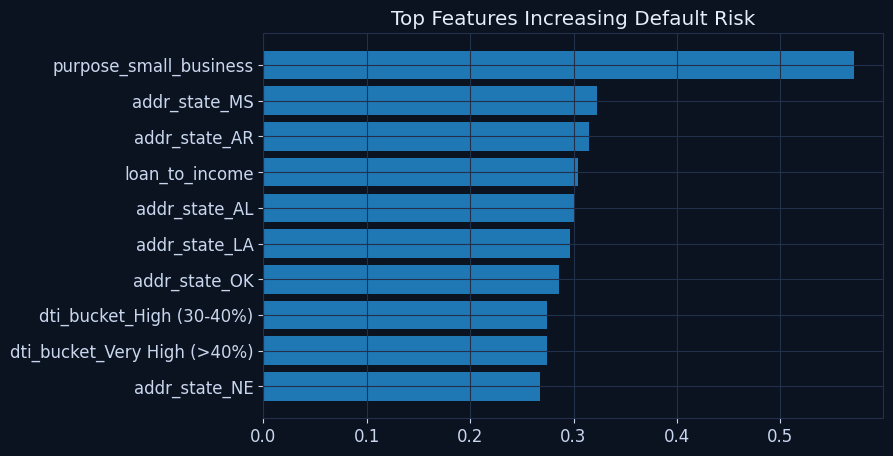

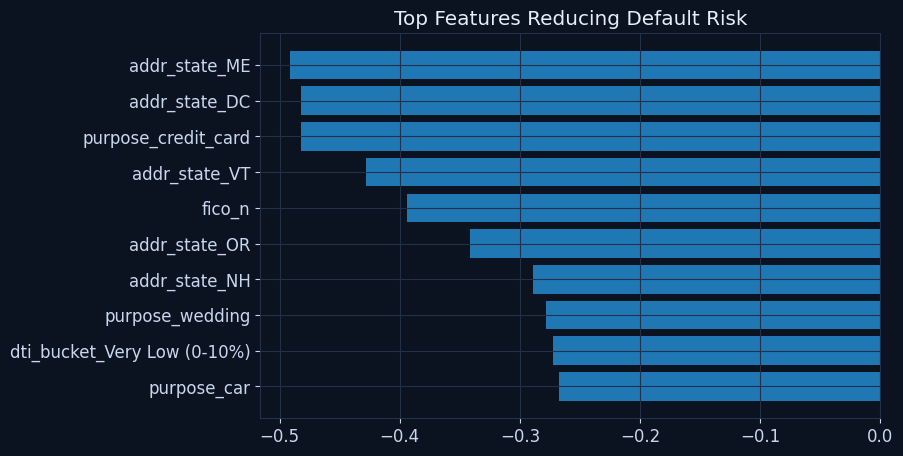

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(top_risk['Feature'], top_risk['Coefficient'])
plt.title('Top Features Increasing Default Risk')
plt.gca().invert_yaxis()
plt.show()

plt.figure(figsize=(8,5))
plt.barh(top_safe['Feature'], top_safe['Coefficient'])
plt.title('Top Features Reducing Default Risk')
plt.gca().invert_yaxis()
plt.show()

In [39]:
thresholds = [0.3, 0.4, 0.5, 0.6]

results = []

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
    
    recall = tp / (tp + fn)
    precision = tp / (tp + fp)
    
    results.append({
        "Threshold": t,
        "True Positives": tp,
        "False Positives": fp,
        "Recall (Default Catch Rate)": recall,
        "Precision": precision
    })

threshold_df = pd.DataFrame(results)
threshold_df

,Threshold,True Positives,False Positives,Recall (Default Catch Rate),Precision
0,0.3,51419,183440,0.954856,0.218936
1,0.4,45458,140022,0.844160,0.245083
2,0.5,34106,84845,0.633352,0.286723
3,0.6,19546,37138,0.362971,0.344824


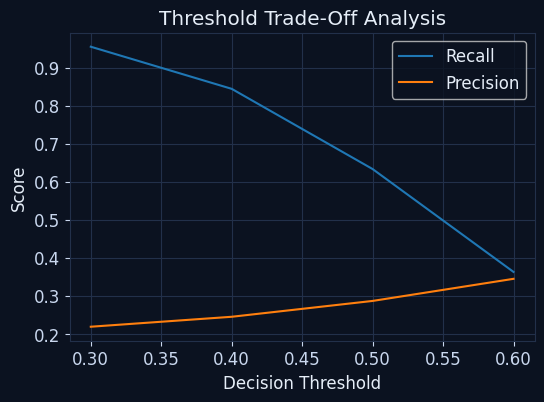

In [40]:
plt.figure(figsize=(6,4))
plt.plot(threshold_df["Threshold"], threshold_df["Recall (Default Catch Rate)"], label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], label="Precision")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Threshold Trade-Off Analysis")
plt.show()